### Fourier calibration

Now we need to do the Fourier calibration which means that the slm (slmsuite) should know what theta /blaze angle to produce on the slm sensor such that it forms a spot at some (i,j) coordinate of the camera.

In [1]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)


In [ ]:
import slmsuite

from slmsuite.hardware.cameraslms import FourierSLM

print("slmsuite version:", slmsuite.__version__)
print("Imports successful.")

slmsuite version: 0.4.1
Imports successful.


In [4]:
from pathlib import Path

from slmsuite.hardware.slms.meadowlark import Meadowlark

print("SLM imports successful.")

SLM imports successful.


In [5]:
# Meadowlark paths

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)


print("SDK exists :", SDK_PATH.exists())
print("LUT exists :", LUT_PATH.exists())

# Initialize SLM

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)


print("\n=== SLM READY ===")
print("Name       :", slm.name)
print("Shape      :", slm.shape)
print("Wavelength :", slm.wav_um, "um")
print("Pixel pitch:", slm.pitch_um, "um")

SDK exists : True
LUT exists : True
Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM READY ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Wavelength : 0.7593 um
Pixel pitch: [8. 8.] um


In [6]:
from slmsuite.hardware.cameras.alliedvision import AlliedVision

CAMERA_SERIAL = "015C2"

cam = AlliedVision(
    serial=CAMERA_SERIAL,
    verbose=True,
)


print("\n=== CAMERA READY ===")
print("Shape     :", cam.shape)
print("WOI       :", cam.woi)
print("Exposure  :", cam.exposure_s, "s")
print("Bit depth :", cam.bitdepth)

vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success

=== CAMERA READY ===
Shape     : (3672, 5496)
WOI       : (0, 5496, 0, 3672)
Exposure  : 0.000139681 s
Bit depth : 8


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


In [11]:
img = cam.get_image(timeout_s=2)

print("Image type :", type(img))
print("Image shape:", None if img is None else img.shape)

if img is not None:
    print("Min        :", img.min())
    print("Max        :", img.max())
    print("Mean       :", img.mean())

Image type : <class 'numpy.ndarray'>
Image shape: (3672, 5496)
Min        : 0
Max        : 255
Mean       : 0.005511485080851037


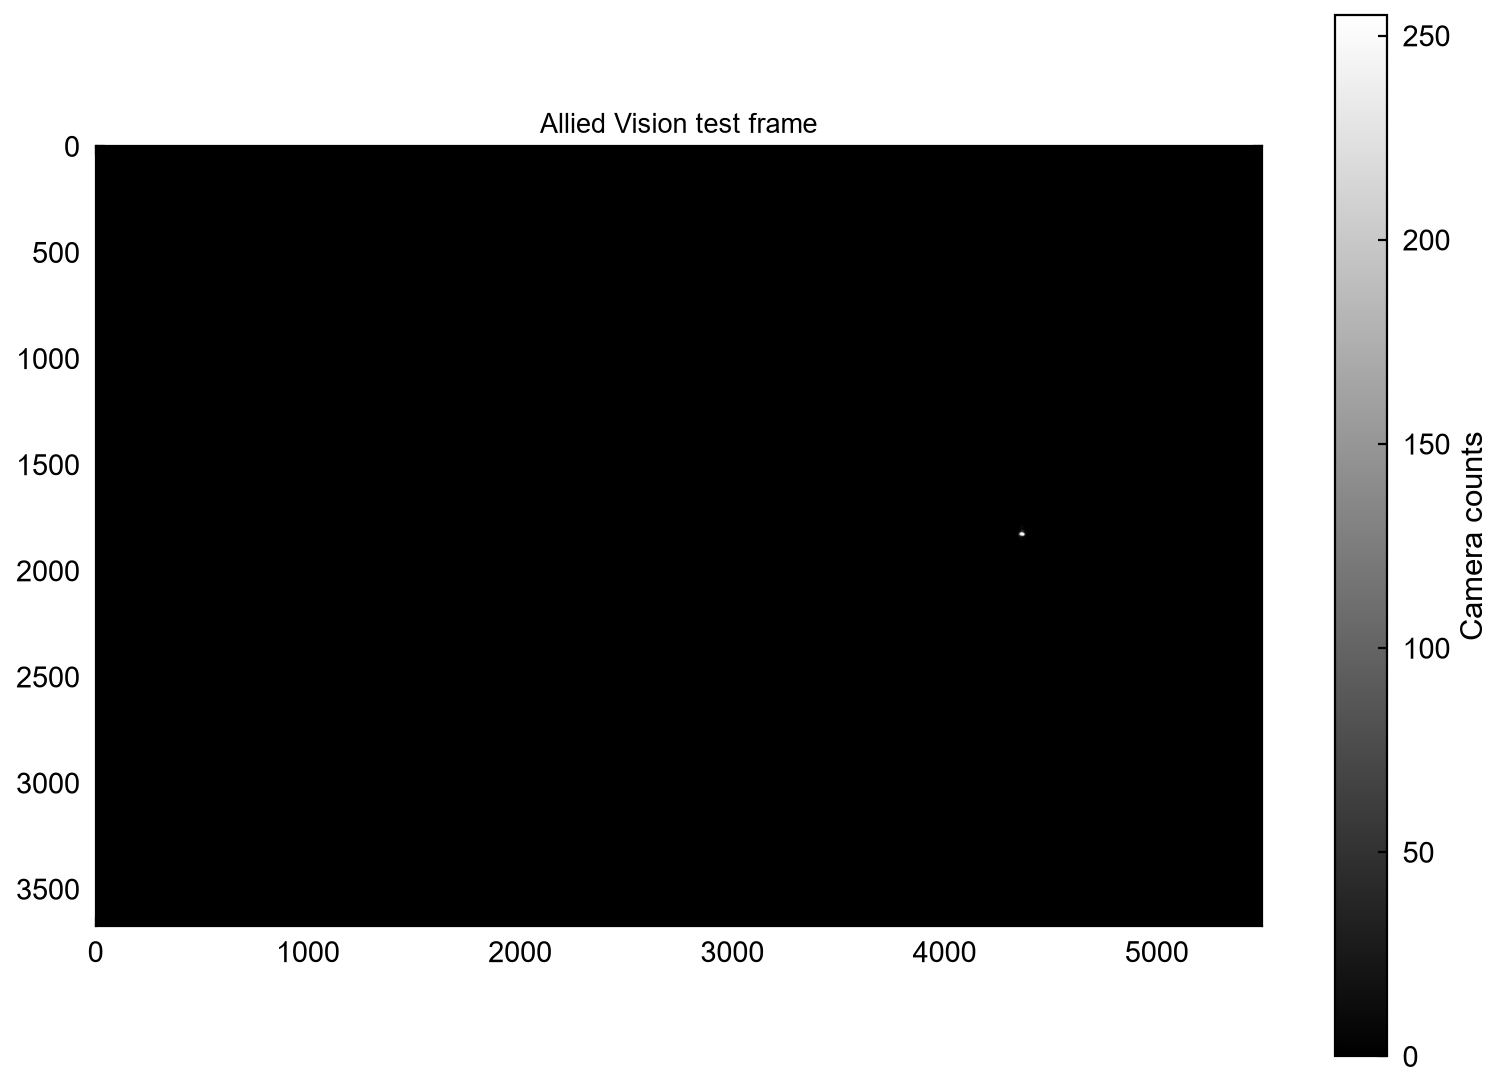

In [12]:
plt.figure(figsize=(10, 7))

plt.imshow(
    img,
    cmap="gray",
    origin="upper"
)

plt.colorbar(label="Camera counts")
plt.title("Allied Vision test frame")

plt.tight_layout()
plt.show()

In [13]:
from slmsuite.hardware.cameraslms import FourierSLM

fs = FourierSLM(cam, slm)

print("FourierSLM created successfully.")
print("Current calibrations:", fs.calibrations.keys())

FourierSLM created successfully.
Current calibrations: dict_keys([])


In [14]:
print("=== SLM ===")
print("Shape       :", slm.shape)
print("Wavelength  :", slm.wav_um, "um")
print("Pixel pitch :", slm.pitch_um, "um")

print("\n=== CAMERA ===")
print("Shape       :", cam.shape)

if hasattr(cam, "pitch_um"):
    print("Pixel pitch :", cam.pitch_um, "um")
else:
    print("Pixel pitch : attribute not available")

print("Exposure    :", cam.exposure_s, "s")
print("Bit depth   :", cam.bitdepth)

print("\n=== SLM SOURCE DATA ===")
print("Source keys :", slm.source.keys())

if "phase" in slm.source:
    print("WARNING: A phase map is already stored in slm.source!")
else:
    print("Good: no wavefront phase map is stored.")

if "amplitude" in slm.source:
    print("Amplitude map already present.")
else:
    print("Good: no measured amplitude map is stored.")

print("\n=== FOURIER SLM ===")
print("Calibrations:", fs.calibrations.keys())

=== SLM ===
Shape       : (1200, 1920)
Wavelength  : 0.7593 um
Pixel pitch : [8. 8.] um

=== CAMERA ===
Shape       : (3672, 5496)
Pixel pitch : None um
Exposure    : 0.000139681 s
Bit depth   : 8

=== SLM SOURCE DATA ===
Source keys : dict_keys([])
Good: no wavefront phase map is stored.
Good: no measured amplitude map is stored.

=== FOURIER SLM ===
Calibrations: dict_keys([])


In [15]:
# ============================================================
# FOURIER CALIBRATION GRID PARAMETERS
# ============================================================

ARRAY_SHAPE = (9, 9)
ARRAY_PITCH = (13, 13)

# Important:
# This is relative to the zero order in knm coordinates.
# +128 corresponds to our 16-pixel carrier because 2048/16 = 128.
ARRAY_CENTER = (128, 0)

print("Fourier calibration grid:")
print("  array shape  :", ARRAY_SHAPE)
print("  array pitch  :", ARRAY_PITCH, "knm")
print("  array center :", ARRAY_CENTER, "knm relative to zero order")


# Extent of the 9x9 grid relative to zero order
half_x = (ARRAY_SHAPE[0] - 1) // 2
half_y = (ARRAY_SHAPE[1] - 1) // 2

kx_min = ARRAY_CENTER[0] - half_x * ARRAY_PITCH[0]
kx_max = ARRAY_CENTER[0] + half_x * ARRAY_PITCH[0]

ky_min = ARRAY_CENTER[1] - half_y * ARRAY_PITCH[1]
ky_max = ARRAY_CENTER[1] + half_y * ARRAY_PITCH[1]

print()
print("Expected knm extent:")
print(f"  kx: {kx_min} to {kx_max}")
print(f"  ky: {ky_min} to {ky_max}")

Fourier calibration grid:
  array shape  : (9, 9)
  array pitch  : (13, 13) knm
  array center : (128, 0) knm relative to zero order

Expected knm extent:
  kx: 76 to 180
  ky: -52 to 52


In [16]:
holo_fourier_test = fs.fourier_grid_project(
    array_shape=ARRAY_SHAPE,
    array_pitch=ARRAY_PITCH,
    array_center=ARRAY_CENTER,
    method="GS",
    maxiter=30,
)

print("Calibration grid projected.")

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\toolbox\__init__.py:258: UserWarning: CameraSLM must be passed as slm for conversion 'kxy' to 'ij'
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

Calibration grid projected.


In [17]:
print("Object returned:")
print(type(holo_fourier_test))

print("\nCurrent fs calibrations:")
print(fs.calibrations.keys())

Object returned:
<class 'slmsuite.holography.algorithms._spots.SpotHologram'>

Current fs calibrations:
dict_keys([])


In [19]:
import numpy as np

img_fourier_test = cam.get_image(timeout_s=2)

print("Image shape :", img_fourier_test.shape)
print("Min         :", img_fourier_test.min())
print("Max         :", img_fourier_test.max())
print("Mean        :", img_fourier_test.mean())
print("Pixels at 255:", np.sum(img_fourier_test == 255))

Image shape : (3672, 5496)
Min         : 0
Max         : 32
Mean        : 0.001722732397180124
Pixels at 255: 0


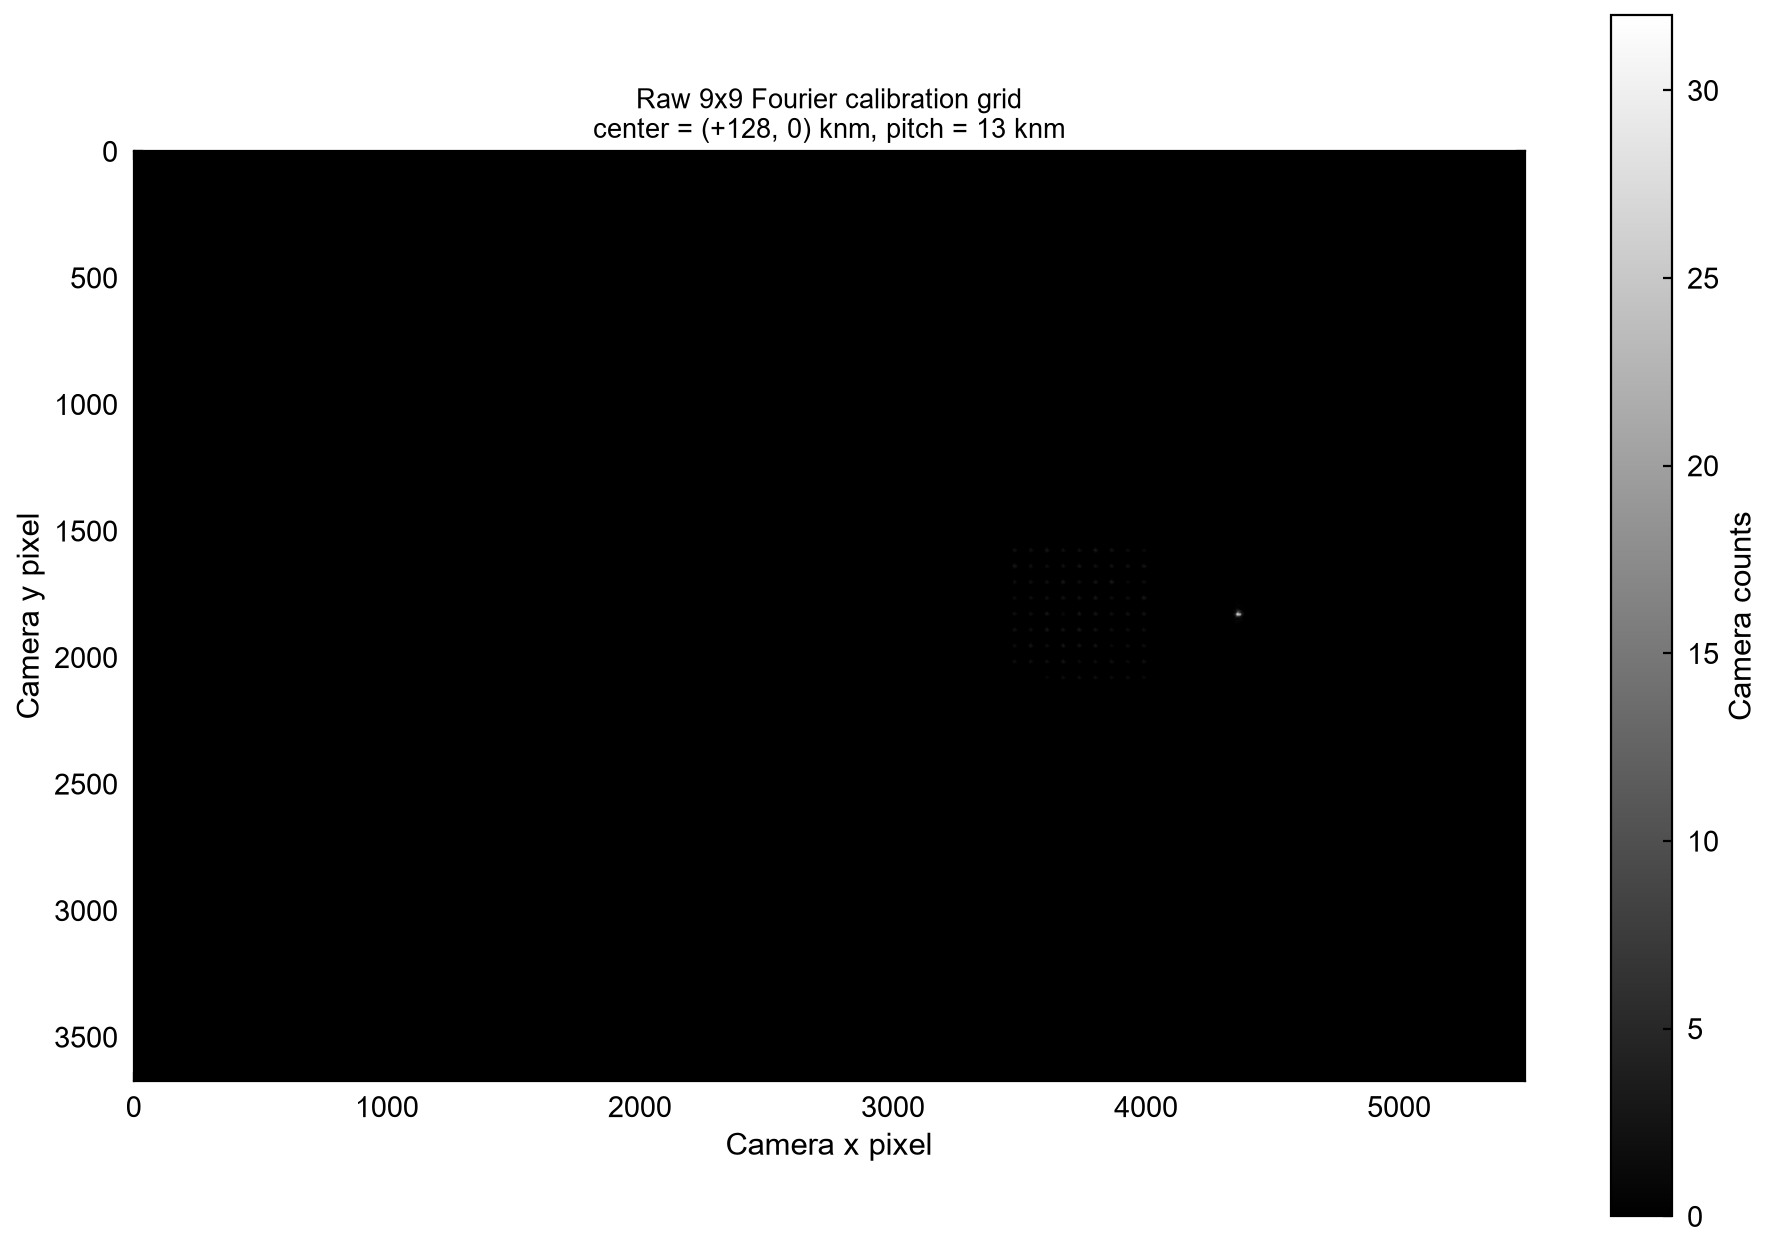

In [20]:
plt.figure(figsize=(12, 8))

plt.imshow(
    img_fourier_test,
    cmap="gray",
    origin="upper"
)

plt.colorbar(label="Camera counts")

plt.title(
    "Raw 9x9 Fourier calibration grid\n"
    "center = (+128, 0) knm, pitch = 13 knm"
)

plt.xlabel("Camera x pixel")
plt.ylabel("Camera y pixel")

plt.tight_layout()
plt.show()

In [27]:
cam.set_exposure(0.0007)

print("New exposure:", cam.exposure_s, "s")

New exposure: 0.000689681 s


In [28]:
img_fourier_test2 = cam.get_image(timeout_s=2)

print("Min          :", img_fourier_test2.min())
print("Max          :", img_fourier_test2.max())
print("Mean         :", img_fourier_test2.mean())
print("Pixels at 255:", np.sum(img_fourier_test2 == 255))

Min          : 0
Max          : 141
Mean         : 0.5504405759149851
Pixels at 255: 0


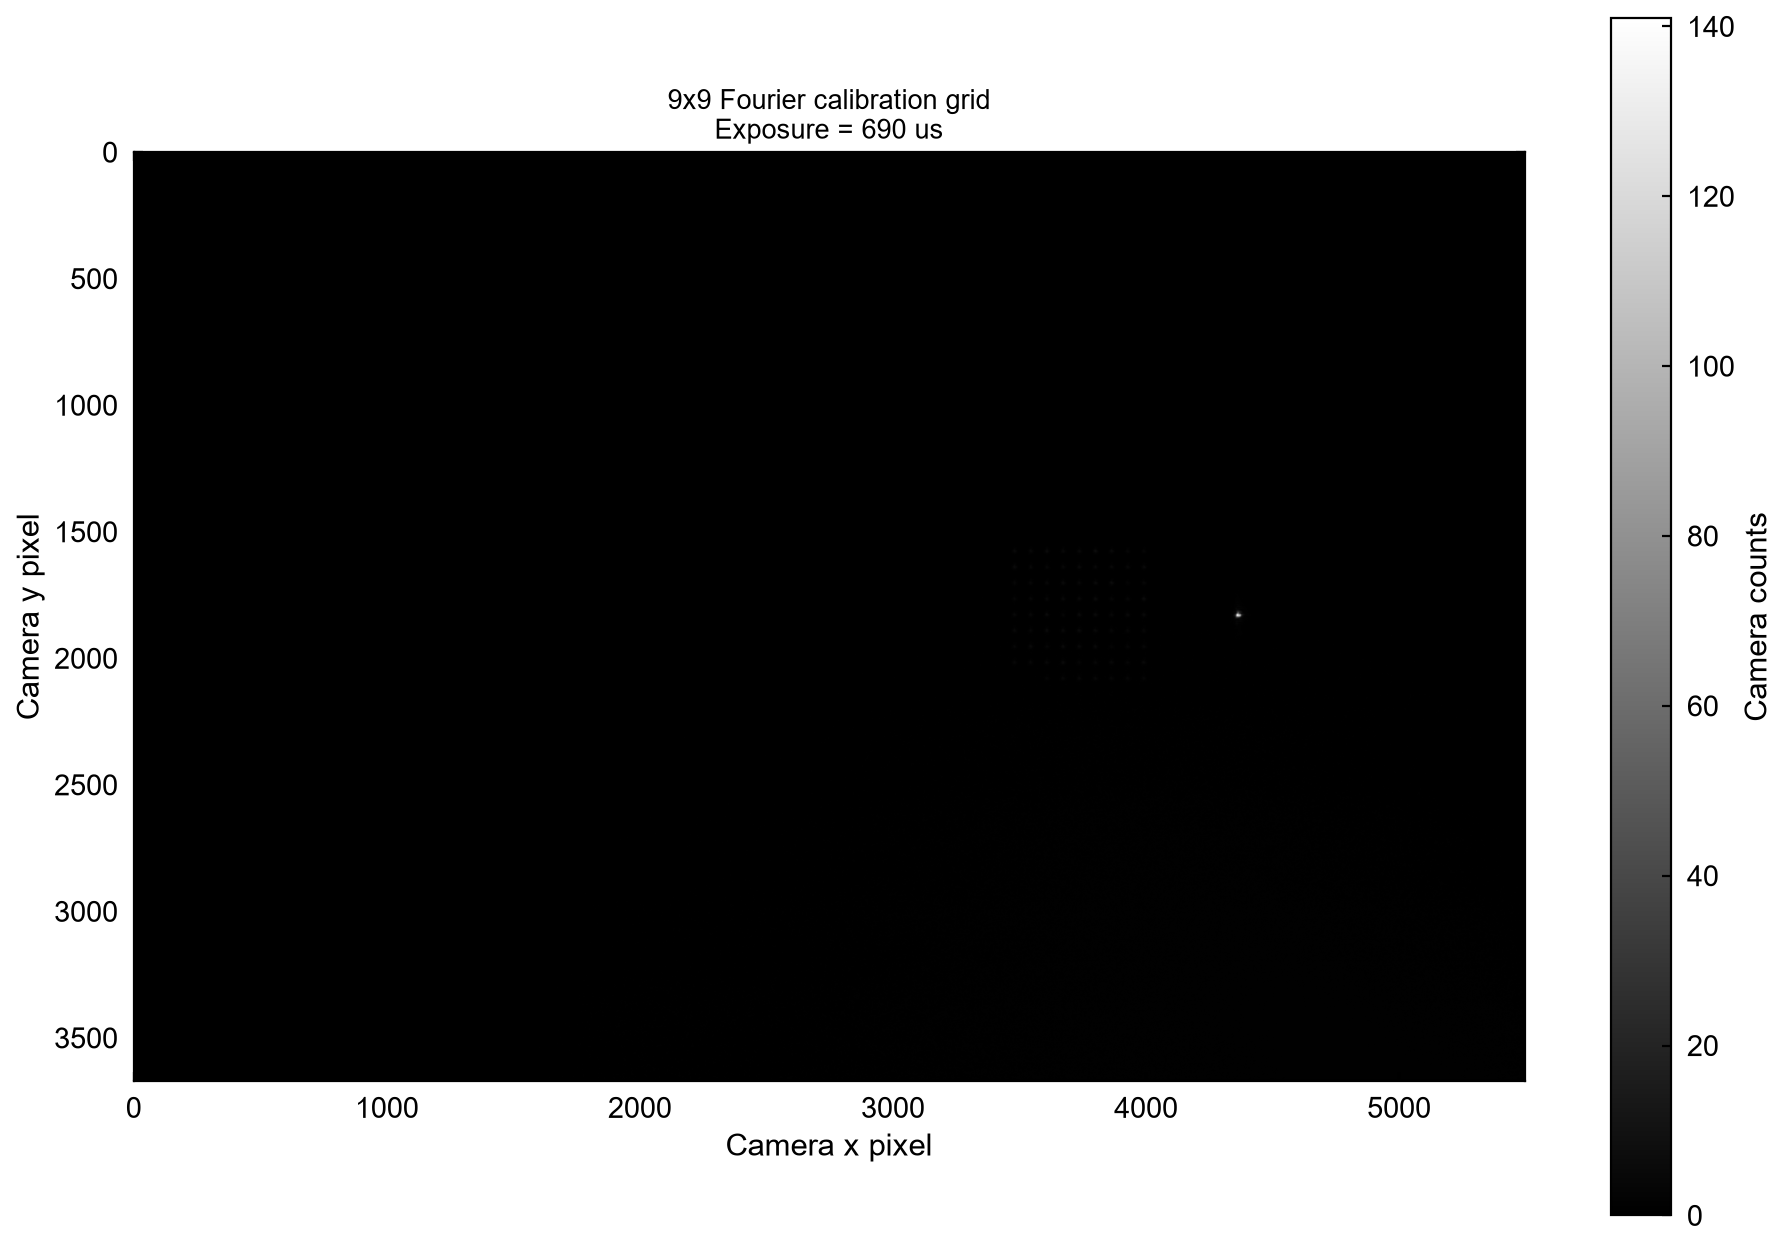

In [29]:
plt.figure(figsize=(12, 8))

plt.imshow(
    img_fourier_test2,
    cmap="gray",
    origin="upper"
)

plt.colorbar(label="Camera counts")

plt.title(
    "9x9 Fourier calibration grid\n"
    f"Exposure = {cam.exposure_s*1e6:.0f} us"
)

plt.xlabel("Camera x pixel")
plt.ylabel("Camera y pixel")

plt.tight_layout()
plt.show()

Crop shape : (750, 700)
Crop min   : 0
Crop max   : 8
Crop mean  : 0.9822057142857142


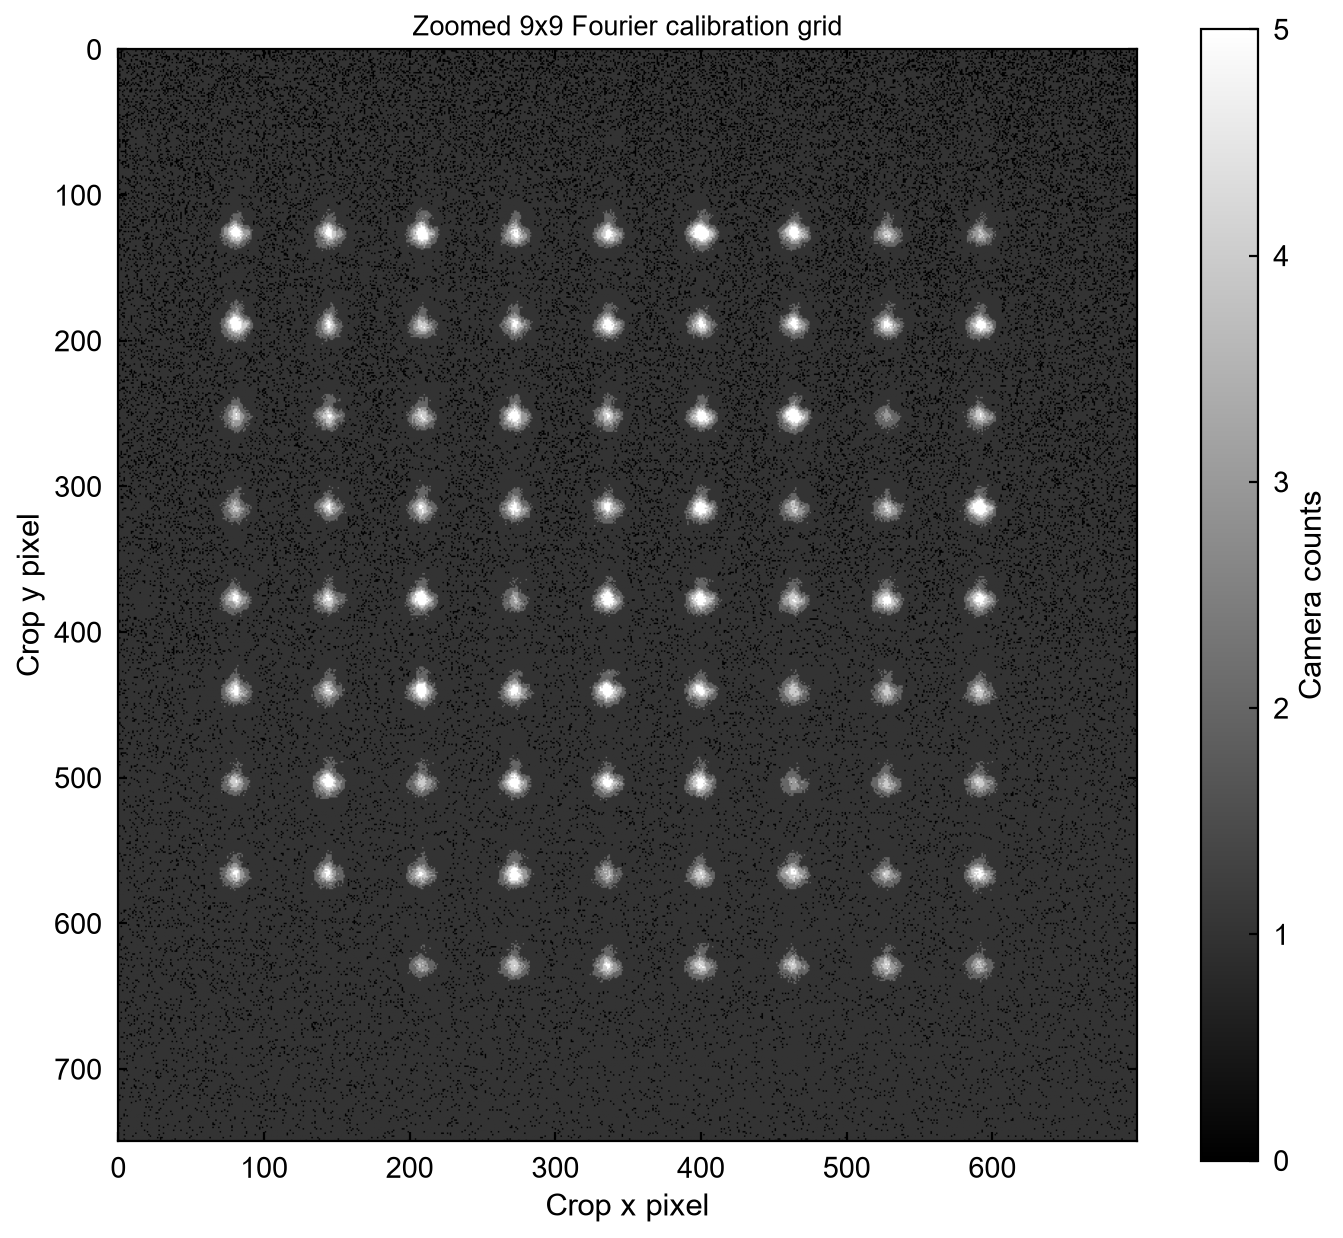

In [30]:
# Crop around the 9x9 calibration array
x1, x2 = 3400, 4100
y1, y2 = 1450, 2200

crop = img_fourier_test2[y1:y2, x1:x2]

print("Crop shape :", crop.shape)
print("Crop min   :", crop.min())
print("Crop max   :", crop.max())
print("Crop mean  :", crop.mean())

plt.figure(figsize=(9, 8))

plt.imshow(
    crop,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=np.percentile(crop, 99.9)
)

plt.colorbar(label="Camera counts")

plt.title("Zoomed 9x9 Fourier calibration grid")

plt.xlabel("Crop x pixel")
plt.ylabel("Crop y pixel")

plt.tight_layout()
plt.show()

Full image max : 175
Crop max       : 12
Crop mean      : 1.822622857142857


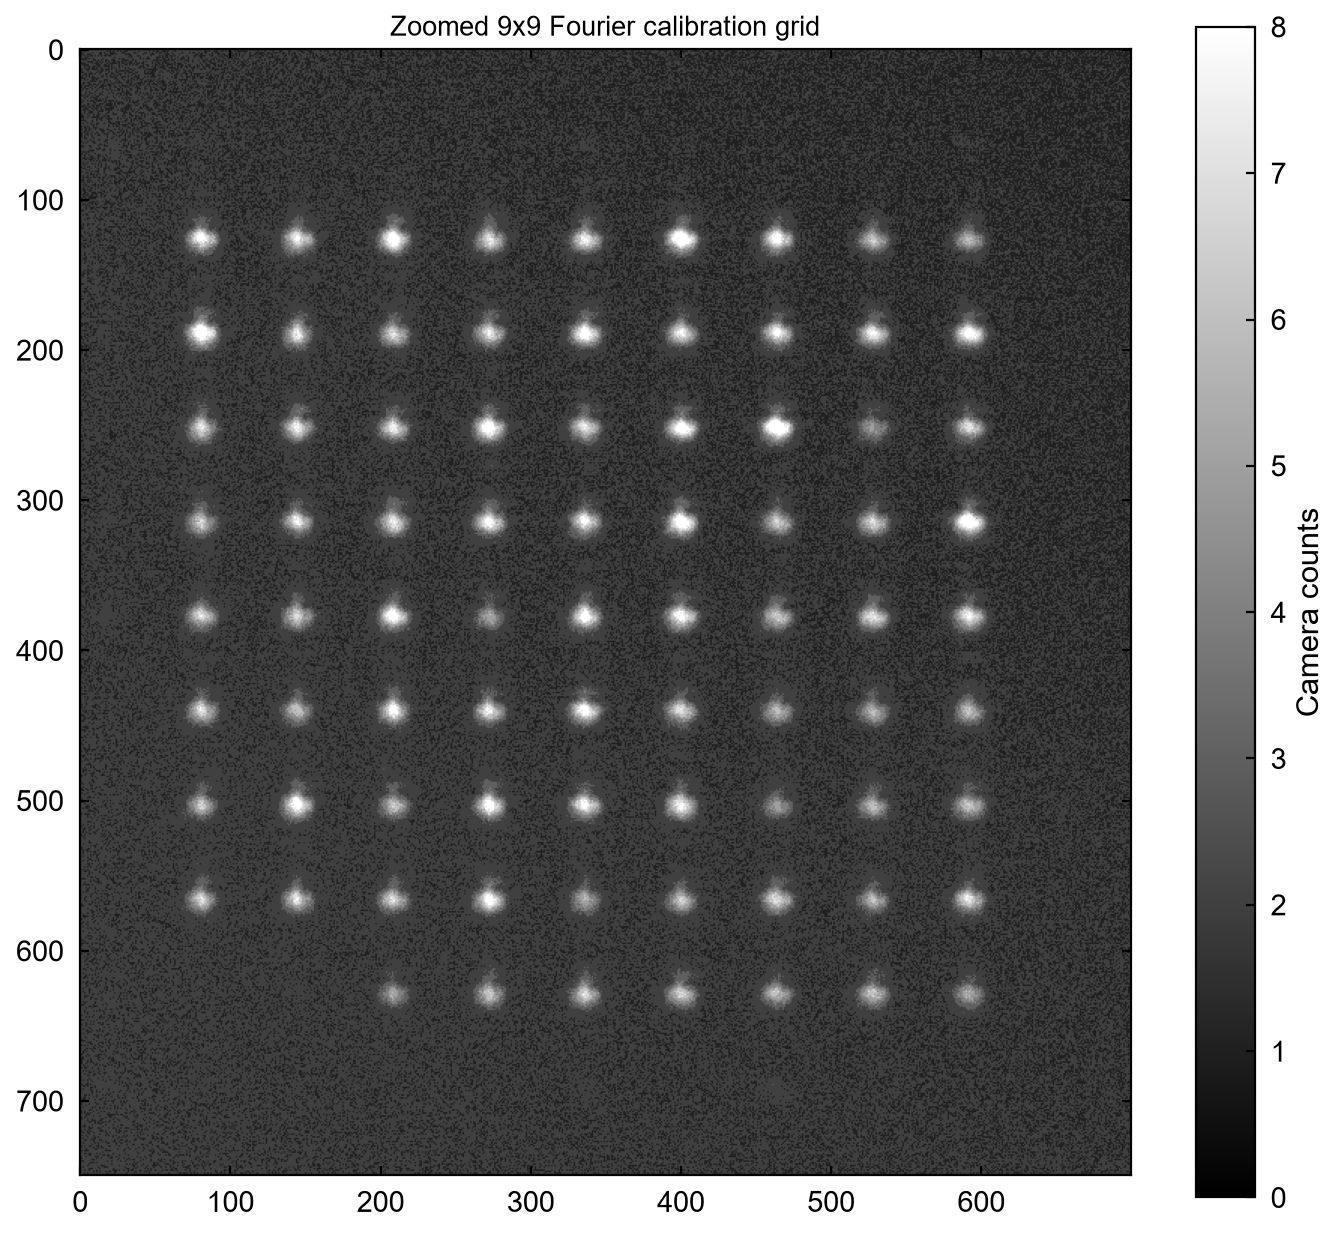

In [31]:
img_fourier_test2 = cam.get_image(timeout_s=2)

crop = img_fourier_test2[1450:2200, 3400:4100]

print("Full image max :", img_fourier_test2.max())
print("Crop max       :", crop.max())
print("Crop mean      :", crop.mean())

plt.figure(figsize=(9, 8))
plt.imshow(
    crop,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=np.percentile(crop, 99.9)
)
plt.colorbar(label="Camera counts")
plt.title("Zoomed 9x9 Fourier calibration grid")
plt.tight_layout()
plt.show()

In [32]:
ARRAY_SHAPE_5 = (5, 5)

holo_fourier_test_5 = fs.fourier_grid_project(
    array_shape=ARRAY_SHAPE_5,
    array_pitch=(13, 13),
    array_center=(128, 0),
    method="GS",
    maxiter=30,
)

print("5x5 Fourier test grid projected.")

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\toolbox\__init__.py:258: UserWarning: CameraSLM must be passed as slm for conversion 'kxy' to 'ij'
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

5x5 Fourier test grid projected.


In [33]:
img_fourier_5 = cam.get_image(timeout_s=2)

crop5 = img_fourier_5[1450:2200, 3400:4100]

print("Full image max :", img_fourier_5.max())
print("Crop max       :", crop5.max())
print("Crop mean      :", crop5.mean())

Full image max : 2
Crop max       : 0
Crop mean      : 0.0


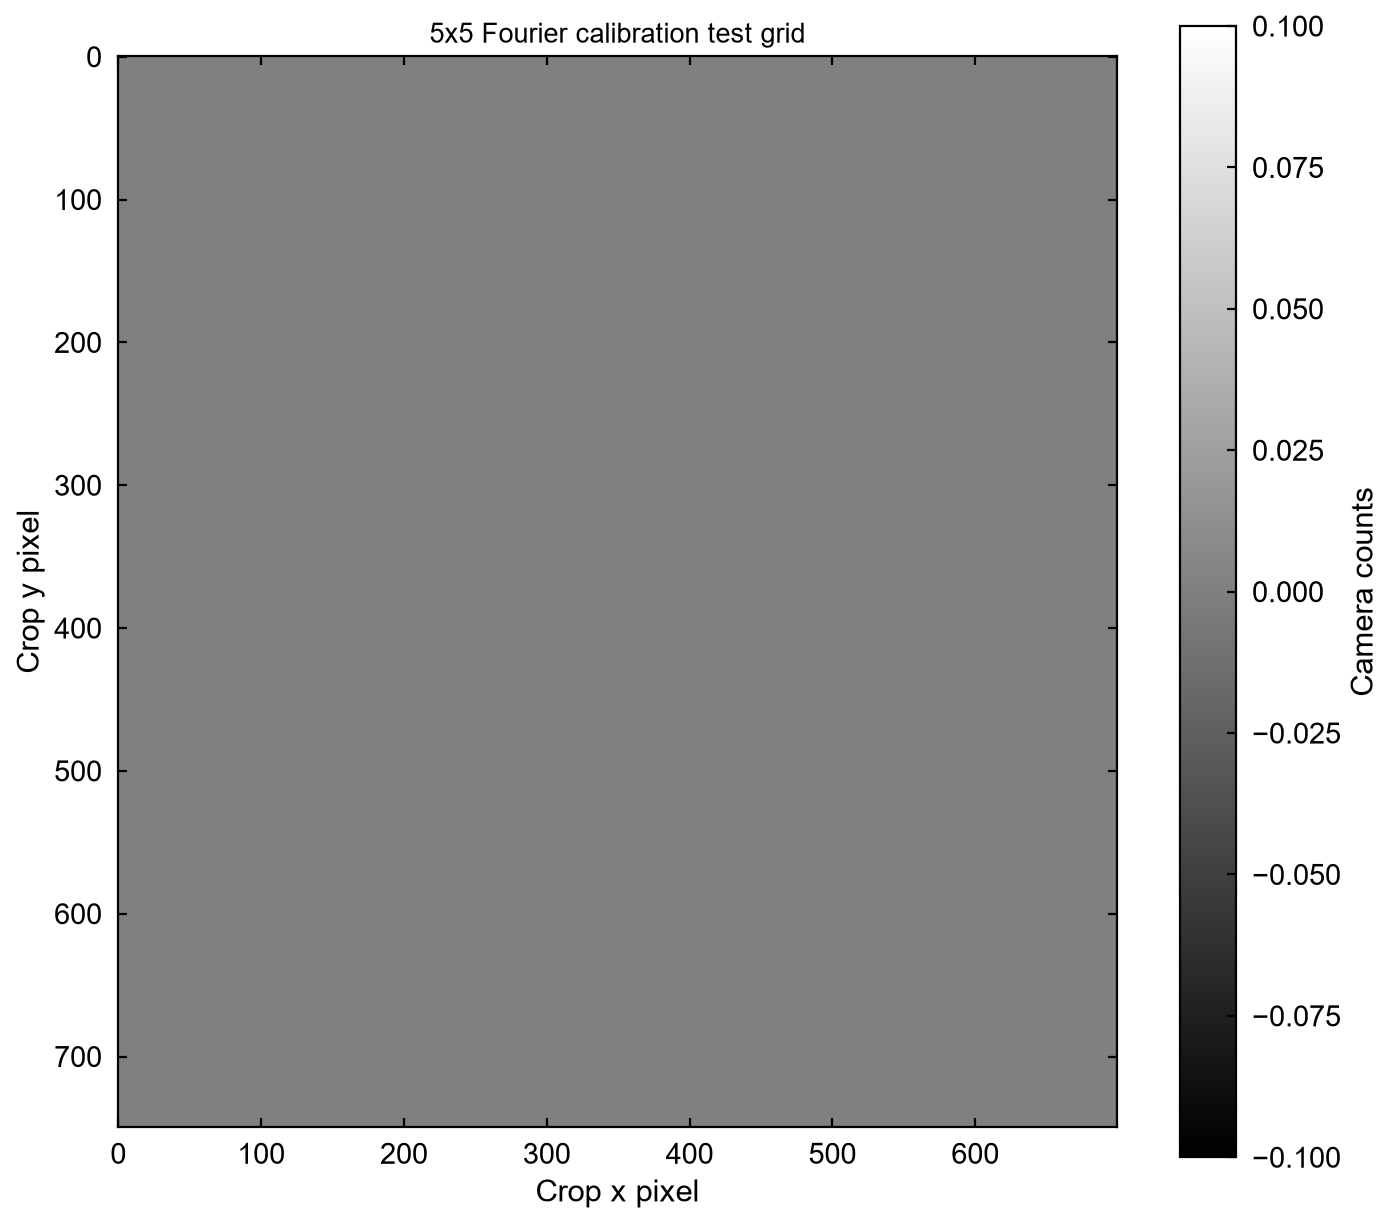

In [34]:
plt.figure(figsize=(9, 8))

plt.imshow(
    crop5,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=np.percentile(crop5, 99.9)
)

plt.colorbar(label="Camera counts")
plt.title("5x5 Fourier calibration test grid")

plt.xlabel("Crop x pixel")
plt.ylabel("Crop y pixel")

plt.tight_layout()
plt.show()

In [35]:
img_fourier_5 = cam.get_image(timeout_s=2)

print("Full image shape :", img_fourier_5.shape)
print("Full image min   :", img_fourier_5.min())
print("Full image max   :", img_fourier_5.max())
print("Full image mean  :", img_fourier_5.mean())

# Location of brightest camera pixel
iy, ix = np.unravel_index(
    np.argmax(img_fourier_5),
    img_fourier_5.shape
)

print()
print("Brightest pixel:")
print("  camera x =", ix)
print("  camera y =", iy)
print("  value    =", img_fourier_5[iy, ix])

Full image shape : (3672, 5496)
Full image min   : 0
Full image max   : 192
Full image mean  : 1.3596854852647835

Brightest pixel:
  camera x = 4362
  camera y = 1828
  value    = 192


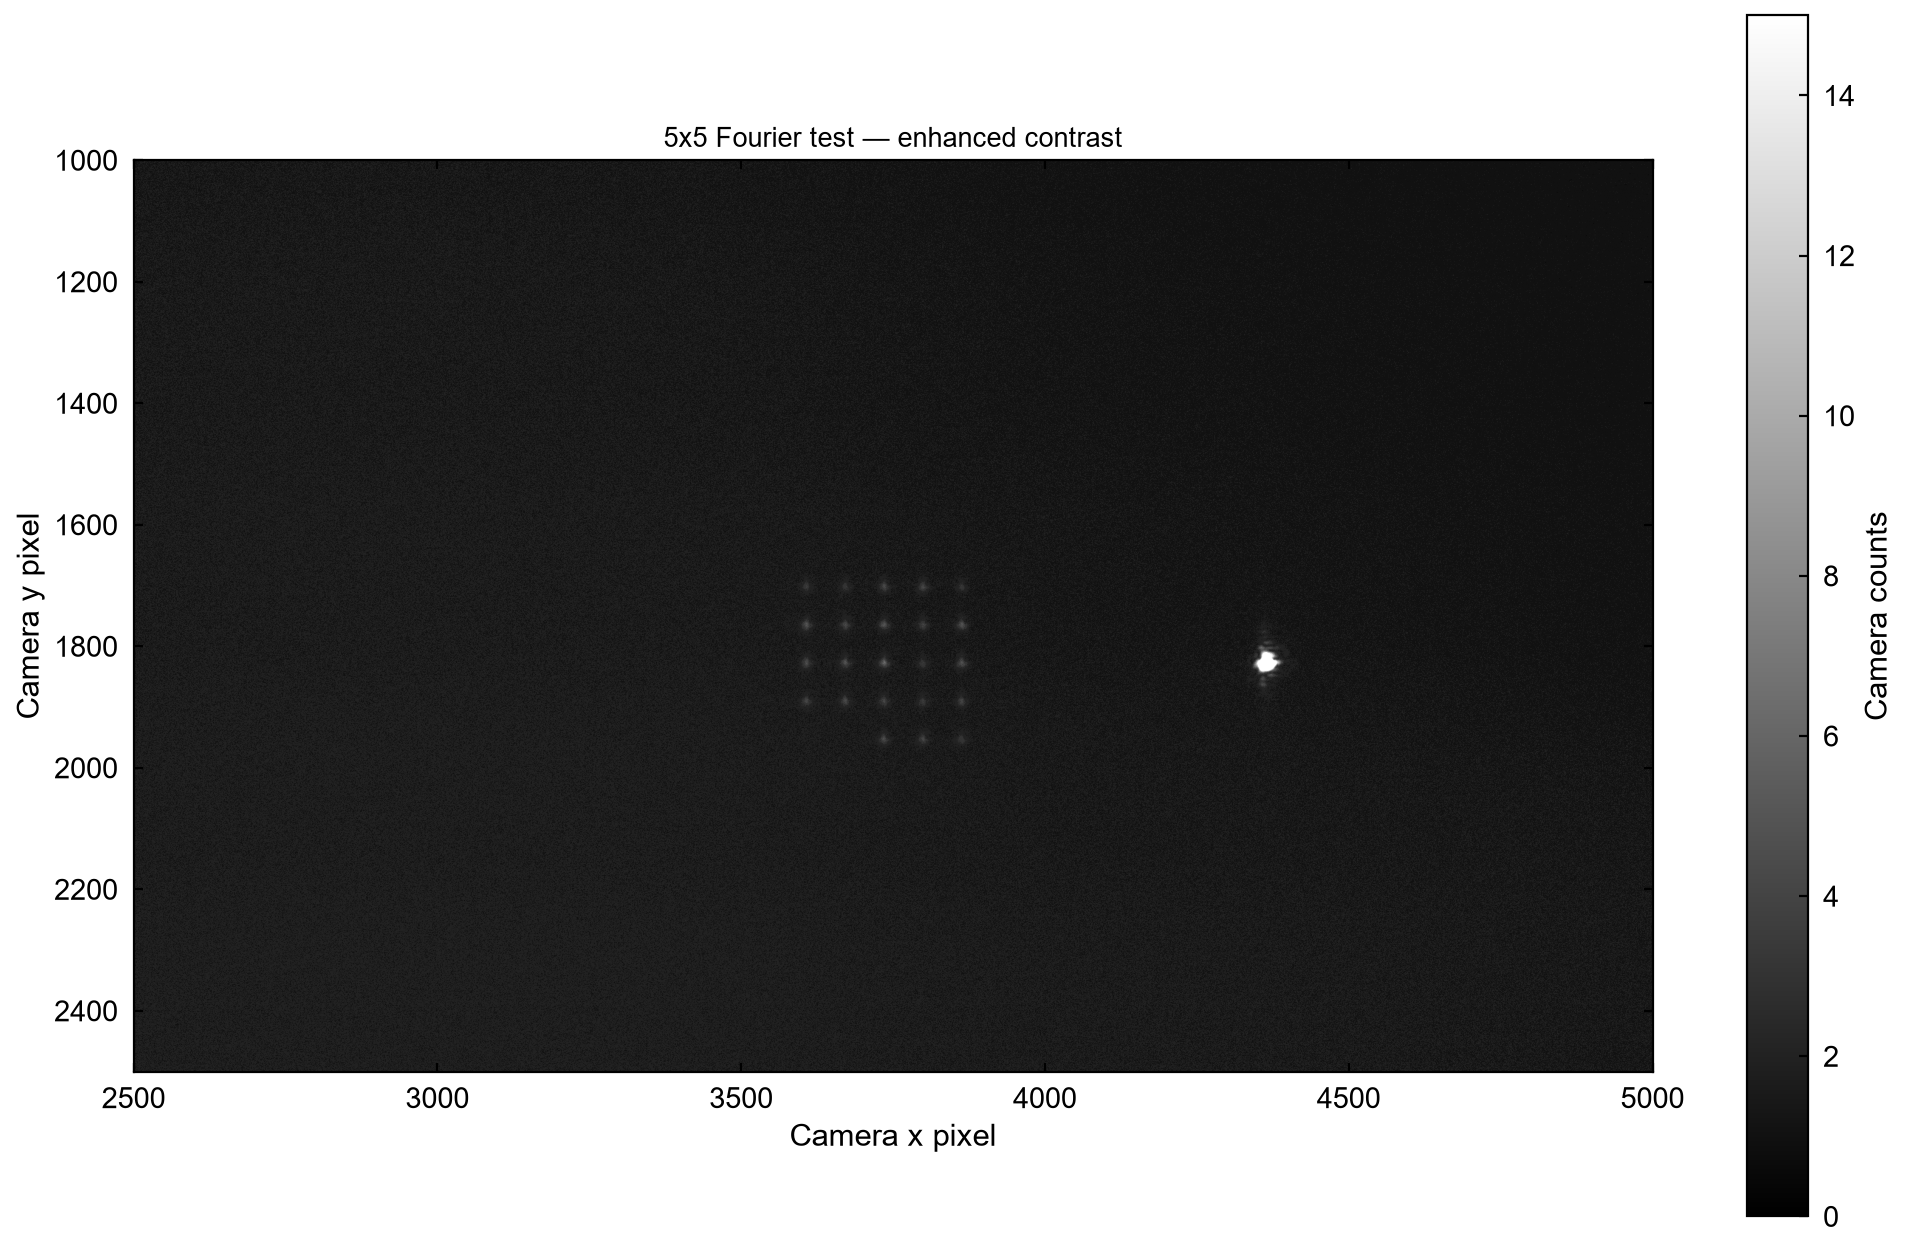

In [36]:
plt.figure(figsize=(13, 8))

plt.imshow(
    img_fourier_5,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=15,      # deliberately ignore the bright zero order
)

plt.xlim(2500, 5000)
plt.ylim(2500, 1000)

plt.colorbar(label="Camera counts")
plt.title("5x5 Fourier test — enhanced contrast")

plt.xlabel("Camera x pixel")
plt.ylabel("Camera y pixel")

plt.tight_layout()
plt.show()

In [37]:
cam.flush()

img = cam.get_image(timeout_s=2)

print("Max:", img.max())

Max: 148


In [38]:
img_masked = img.copy()

# Zeroth-order position from your measured image
x0 = 4362
y0 = 1828

# Mask radius in camera pixels
r = 100

yy, xx = np.indices(img_masked.shape)

zero_mask = (xx - x0)**2 + (yy - y0)**2 < r**2

img_masked[zero_mask] = 0

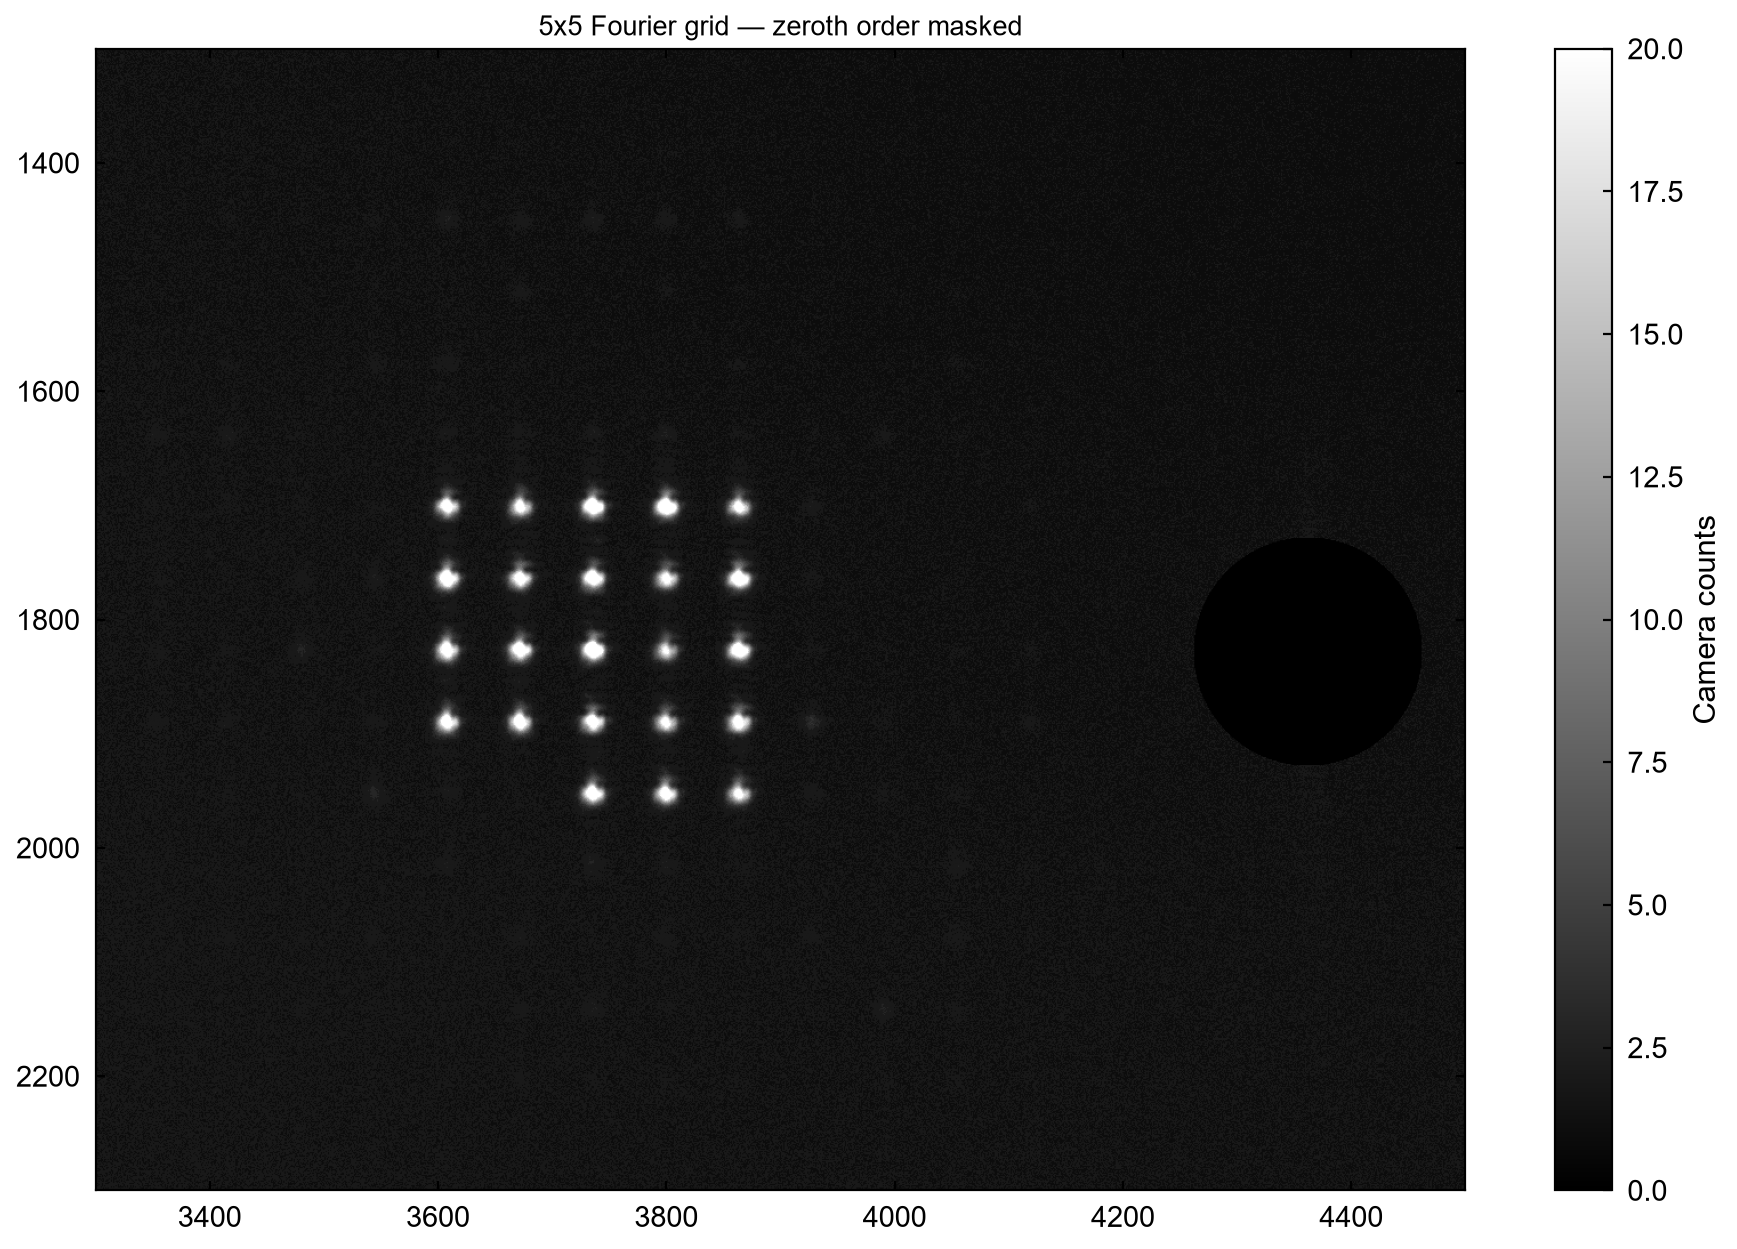

In [39]:
plt.figure(figsize=(12, 8))

plt.imshow(
    img_masked,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=np.percentile(img_masked, 99.99)
)

plt.xlim(3300, 4500)
plt.ylim(2300, 1300)

plt.colorbar(label="Camera counts")
plt.title("5x5 Fourier grid — zeroth order masked")

plt.tight_layout()
plt.show()

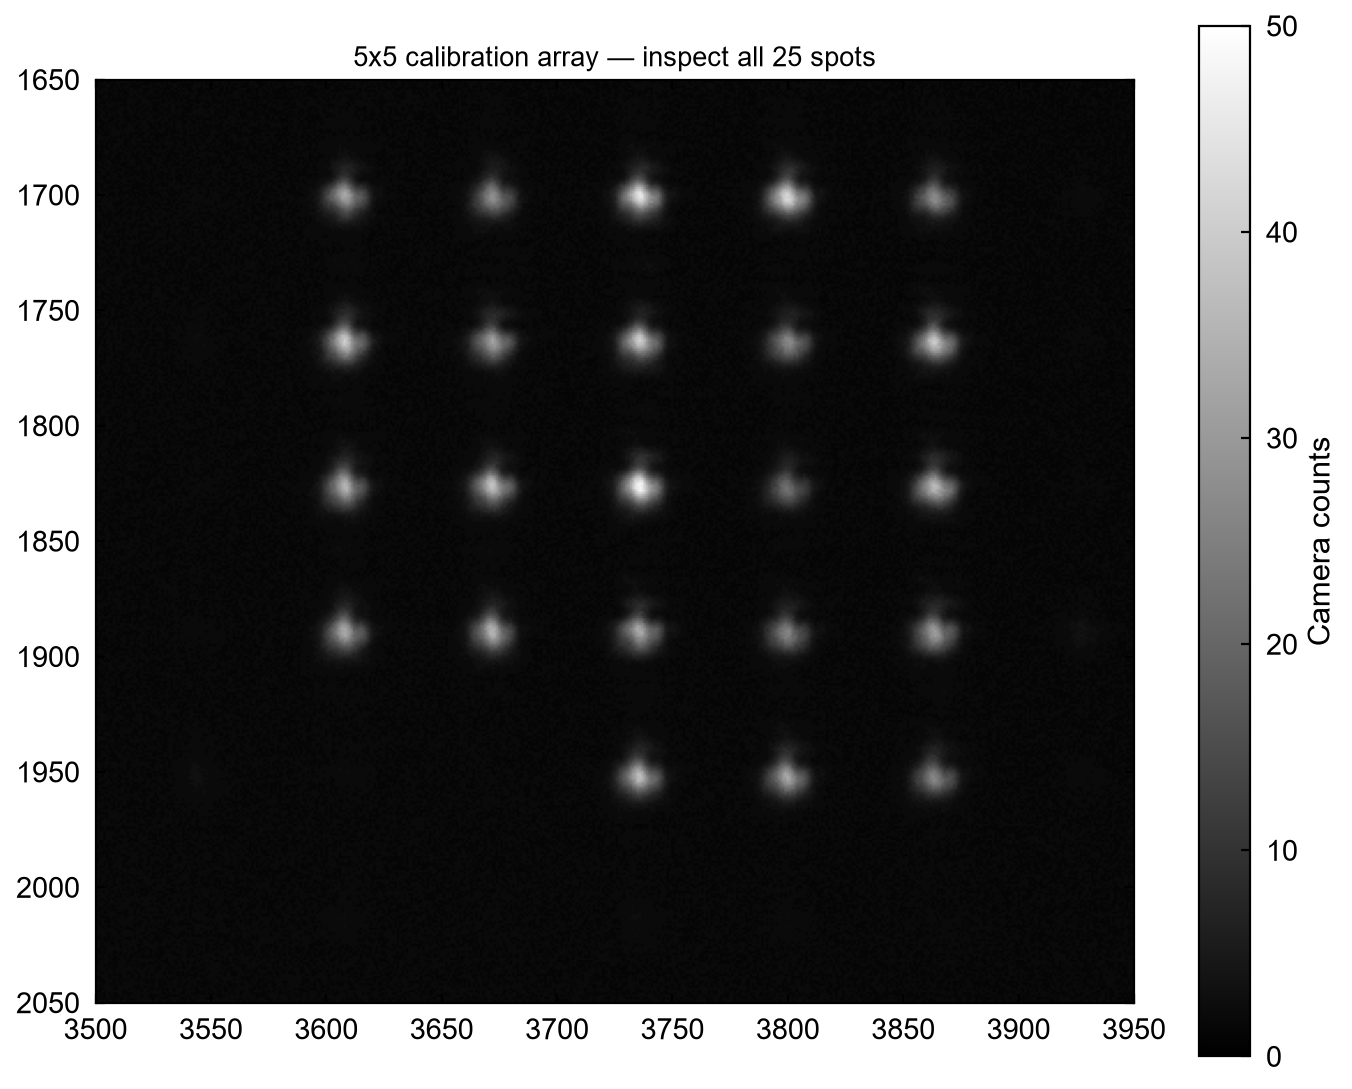

In [40]:
# Show the array region with a larger display range
plt.figure(figsize=(9, 7))

plt.imshow(
    img_masked,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=50,
)

plt.xlim(3500, 3950)
plt.ylim(2050, 1650)

plt.colorbar(label="Camera counts")
plt.title("5x5 calibration array — inspect all 25 spots")

plt.tight_layout()
plt.show()

In [41]:
array_region = img_masked[1650:2050, 3500:3950]

print("Array-region max :", array_region.max())
print("Array-region mean:", array_region.mean())

Array-region max : 48
Array-region mean: 2.358616666666667


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\analysis\__init__.py:2261: UserWarning: The fitted spot array approaches or exceeds the camera FOV; calibration results may be improperly centered as a result.
  warnings.warn(
c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\analysis\__init__.py:2267: UserWarning: 98.9% of the image's power outside the spot array. This might have caused the array fit to be poor.
  warnings.warn(


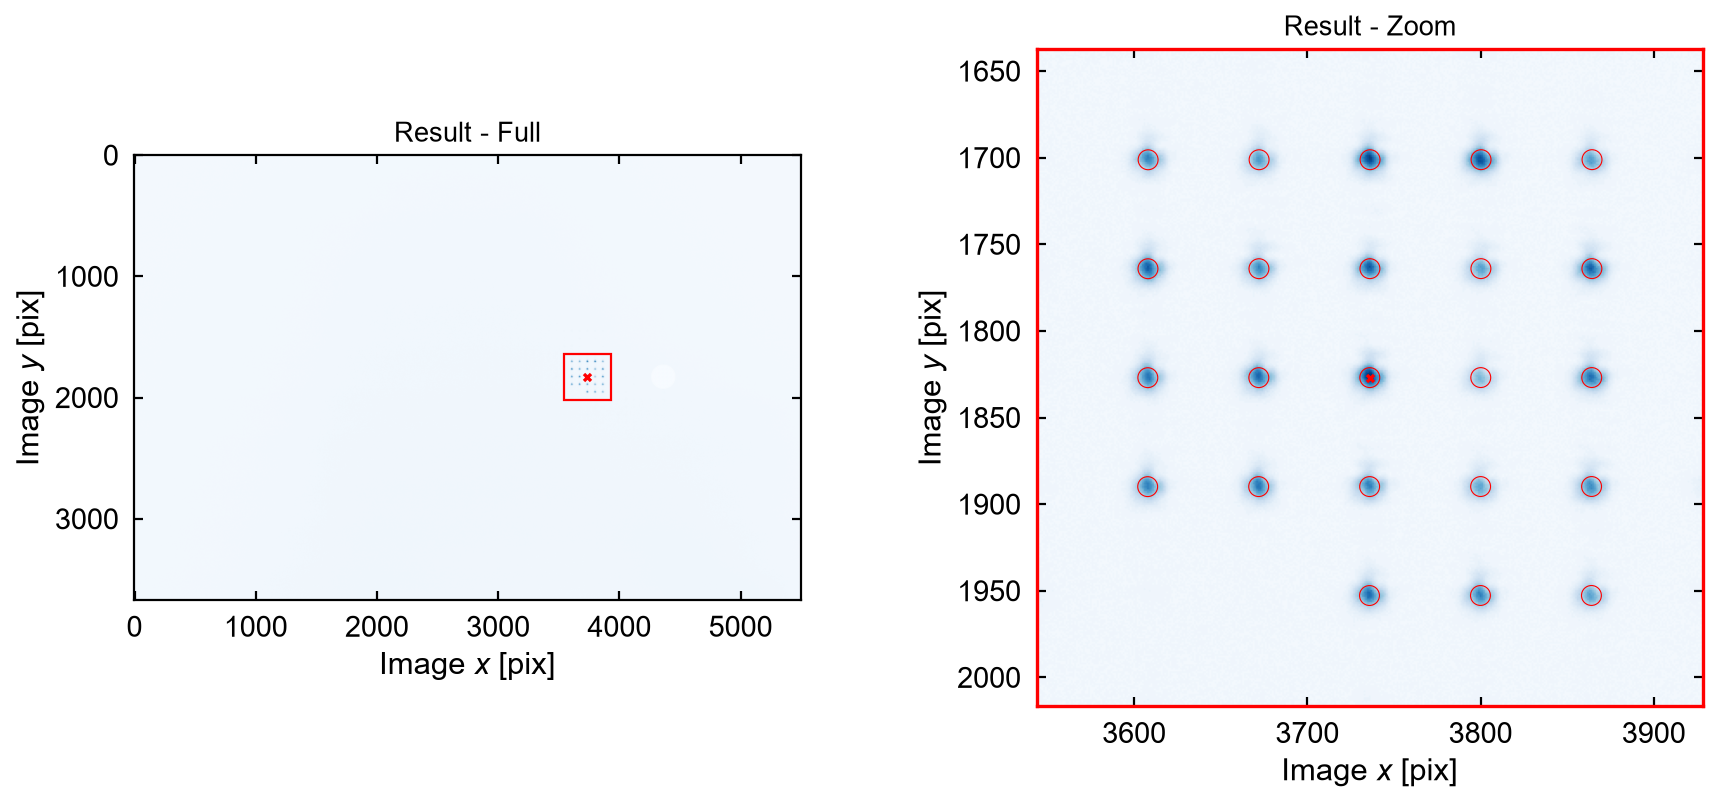


Detected orientation:
M =
[[-6.40651948e+01 -8.49817825e-02]
 [ 1.68356497e-02  6.28969016e+01]]

b =
[[3736.03656654]
 [1826.96085117]]


In [42]:
from slmsuite.holography import analysis

orientation = analysis.blob_array_detect(
    img_masked,
    size=(5, 5),
    orientation_check=True,
    plot=True,
)

print("\nDetected orientation:")
print("M =")
print(orientation["M"])

print("\nb =")
print(orientation["b"])

In [43]:
print("orientation keys:")
print(orientation.keys())

print("\nM =")
print(orientation["M"])

print("\nb =")
print(orientation["b"])

orientation keys:
dict_keys(['M', 'b'])

M =
[[-6.40651948e+01 -8.49817825e-02]
 [ 1.68356497e-02  6.28969016e+01]]

b =
[[3736.03656654]
 [1826.96085117]]


In [44]:
from slmsuite.holography.toolbox import format_2vectors

# Known calibration-grid pitch
array_pitch = np.array([13, 13], dtype=float)

# ------------------------------------------------------------
# Actual written center of the hologram
#
# slmsuite deliberately ignores the first two points to balance
# the two omitted orientation/parity-check points.
# This exactly mirrors fourier_calibrate() in v0.4.1.
# ------------------------------------------------------------

array_center_kxy = np.mean(
    holo_fourier_test_5.spot_kxy_rounded[:, 2:],
    axis=1
)

print("Actual written center in kxy:")
print(array_center_kxy)


# ------------------------------------------------------------
# Inspect SLM normalized pitch and computational shape
# ------------------------------------------------------------

print("\nSLM pitch (normalized):")
print(slm.pitch)

print("\nHologram computational shape:")
print(holo_fourier_test_5.shape)


# ------------------------------------------------------------
# Scaling used internally by slmsuite fourier_calibrate()
# ------------------------------------------------------------

scaling = (
    slm.pitch
    * np.flip(np.squeeze(holo_fourier_test_5.shape))
    / array_pitch
)

print("\nScaling:")
print(scaling)


# ------------------------------------------------------------
# Convert the blob-array M into the actual Fourier M
# ------------------------------------------------------------

M_blob = np.array(orientation["M"])

M_fourier = np.array([
    [
        M_blob[0, 0] * scaling[0],
        M_blob[0, 1] * scaling[1]
    ],
    [
        M_blob[1, 0] * scaling[0],
        M_blob[1, 1] * scaling[1]
    ]
])

a_fourier = format_2vectors(array_center_kxy)
b_fourier = format_2vectors(orientation["b"])


print("\nCandidate Fourier calibration:")
print("\nM_fourier =")
print(M_fourier)

print("\na =")
print(a_fourier)

print("\nb =")
print(b_fourier)

Actual written center in kxy:
[5.93203125e-03 2.06514700e-20]

SLM pitch (normalized):
[10.53602002 10.53602002]

Hologram computational shape:
(np.int64(2048), np.int64(2048))

Scaling:
[1659.82838444 1659.82838444]

Candidate Fourier calibration:

M_fourier =
[[-1.06337229e+05 -1.41055175e+02]
 [ 2.79442892e+01  1.04398063e+05]]

a =
[[5.93203125e-03]
 [2.06514700e-20]]

b =
[[3736.03656654]
 [1826.96085117]]


In [45]:
# ============================================================
# SANITY CHECK: PREDICT ZERO-ORDER CAMERA POSITION
# ============================================================

kxy_zero = np.array([
    [0.0],
    [0.0]
])

ij_zero_pred = (
    M_fourier @ (kxy_zero - a_fourier)
    + b_fourier
)

print("Predicted zero-order camera position:")
print("x =", ij_zero_pred[0, 0])
print("y =", ij_zero_pred[1, 0])


# Carrier displacement from zero order to array center
carrier_displacement = b_fourier - ij_zero_pred

print("\nPredicted carrier displacement:")
print("dx =", carrier_displacement[0, 0], "camera pixels")
print("dy =", carrier_displacement[1, 0], "camera pixels")

print(
    "magnitude =",
    np.linalg.norm(carrier_displacement),
    "camera pixels"
)

Predicted zero-order camera position:
x = 4366.832330787704
y = 1826.7950847761629

Predicted carrier displacement:
dx = -630.7957642517408 camera pixels
dy = 0.16576639704908303 camera pixels
magnitude = 630.7957860325608 camera pixels


In [46]:
# ============================================================
# INSTALL THE VERIFIED FOURIER CALIBRATION INTO slmsuite
# ============================================================

b_zero = ij_zero_pred

fourier_cal = fs.fourier_calibrate_analytic(
    M_fourier,
    b_zero
)

print("Fourier calibration installed.")

print("\nCurrent calibrations:")
print(fs.calibrations.keys())

print("\nStored M:")
print(fs.calibrations["fourier"]["M"])

print("\nStored a:")
print(fs.calibrations["fourier"]["a"])

print("\nStored b:")
print(fs.calibrations["fourier"]["b"])

Fourier calibration installed.

Current calibrations:
dict_keys(['fourier'])

Stored M:
[[-1.06337229e+05 -1.41055175e+02]
 [ 2.79442892e+01  1.04398063e+05]]

Stored a:
[[0]
 [0]]

Stored b:
[[4366.83233079]
 [1826.79508478]]


In [47]:
from slmsuite.holography.toolbox import convert_vector


# ============================================================
# ZERO ORDER
# ============================================================

kxy_zero = np.array([
    [0.0],
    [0.0]
])

ij_zero = fs.kxyslm_to_ijcam(kxy_zero)


# ============================================================
# 16-PIXEL CARRIER
#
# "freq" means cycles per SLM pixel.
# 1/16 therefore corresponds to a 16-pixel blaze.
# ============================================================

kxy_carrier = convert_vector(
    (1/16, 0),
    from_units="freq",
    to_units="kxy",
    hardware=fs,
)

ij_carrier = fs.kxyslm_to_ijcam(kxy_carrier)


# ============================================================
# PRINT
# ============================================================

print("Zero order:")
print("  kxy =", kxy_zero.ravel())
print("  ij  =", ij_zero.ravel())

print("\n16-pixel carrier:")
print("  kxy =", np.asarray(kxy_carrier).ravel())
print("  ij  =", np.asarray(ij_carrier).ravel())

print("\nCarrier displacement:")
print(
    np.asarray(ij_carrier).ravel()
    - np.asarray(ij_zero).ravel()
)

Zero order:
  kxy = [0. 0.]
  ij  = [4366.83233079 1826.79508478]

16-pixel carrier:
  kxy = [0.00593203 0.        ]
  ij  = [3736.03656654 1826.96085117]

Carrier displacement:
[-6.30795764e+02  1.65766397e-01]


In [48]:
fourier_path = fs.save_calibration(
    "fourier",
    path=".",
    name="YDFC_fourier_pre_wavefront"
)

print("Saved to:")
print(fourier_path)

Saved to:
c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5
